## Survival Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from lifelines import KaplanMeierFitter
from lifelines import CoxPHFitter
from lifelines.plotting import plot_lifetimes

from sklearn.preprocessing import OneHotEncoder

In [2]:
train_data_processed = pd.read_csv('data/processed/train_data_processed.csv', index_col=0)
train_labels = pd.read_csv('data/train_data/train_labels.csv', index_col=False)

test_data_processed = pd.read_csv('data/processed/test_data_processed.csv', index_col=0)
test_labels = pd.read_csv('data/test_data/test_labels.csv', index_col=False)

combined_data = pd.concat([train_data_processed,test_data_processed], ignore_index=True)

combined_labels = pd.concat([train_labels,test_labels], ignore_index=True)

combined_data

,sales_IT,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,...,salary_medium,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,monthly_hrs_per_proj,satis_eval_interaction,Work_accident,promotion_last_5years
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.555391,-0.619346,-0.653412,-0.260887,0.340617,0.296779,0.738893,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,-1.818394,0.372007,0.156954,-0.100652,1.024071,-0.422321,-1.411591,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.752109,0.488637,-0.653412,-0.521269,-1.026293,0.068772,0.871858,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.189811,0.838527,0.156954,-1.783117,1.707526,-1.527280,0.550969,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,-2.019214,1.246731,2.588050,1.661929,0.340617,-0.865808,-1.511314,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,-0.011009,0.138748,-1.463777,-1.162207,1.707526,0.761564,0.035953,0.0,0.0
14995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,1.274242,1.013472,-0.653412,1.081079,2.390981,1.471894,1.703774,1.0,0.0
14996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.671781,-0.619346,-0.653412,-0.160741,-0.342838,0.384474,0.144097,0.0,0.0
14997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,1.113586,0.255377,-1.463777,1.541753,-1.026293,4.313217,1.033188,0.0,0.0


In [3]:

data = pd.read_csv('data/raw/turnover.csv')
data

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


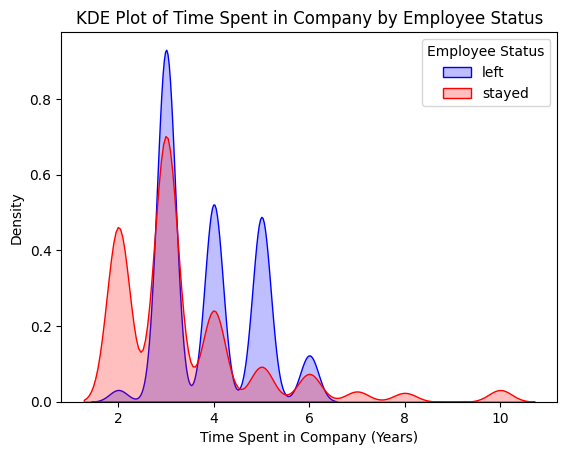

In [4]:
plt.figure()
sns.kdeplot(data[data['left']==1]['time_spend_company'], color='blue', fill=True, label='left')
sns.kdeplot(data[data['left']==0]['time_spend_company'], color='red', fill=True, label='stayed')
plt.legend(title='Employee Status')
plt.xlabel('Time Spent in Company (Years)')
plt.ylabel('Density')
plt.title('KDE Plot of Time Spent in Company by Employee Status')
plt.show()

Kaplan Meier Baseline

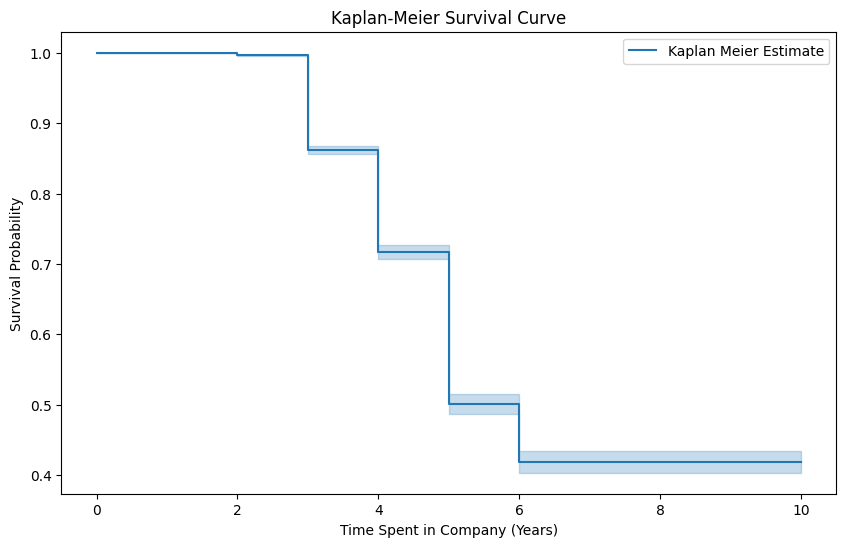

In [5]:
# Applying a baseline KaplanMeier curve without breaking it up into covariates
km = KaplanMeierFitter()

# Fitting the data
km.fit(data['time_spend_company'], data['left'], label='Kaplan Meier Estimate')

# show baseline estimate
# Plotting the survival function
plt.figure(figsize=(10, 6))
km.plot()
plt.title('Kaplan-Meier Survival Curve')
plt.xlabel('Time Spent in Company (Years)')
plt.ylabel('Survival Probability')
plt.show()

<Axes: xlabel='timeline'>

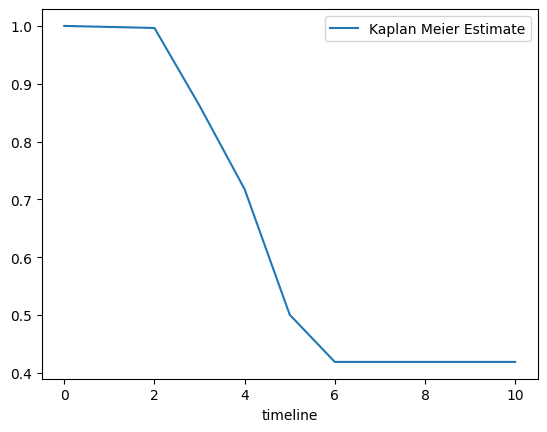

In [6]:
km.survival_function_.plot()

<Axes: xlabel='timeline'>

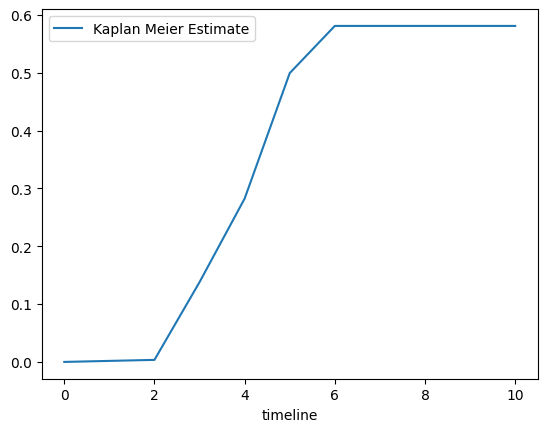

In [7]:
km.cumulative_density_.plot()

In [8]:
km.median_survival_time_

6.0

Kaplan Meier Survival Analysis Split by Salary

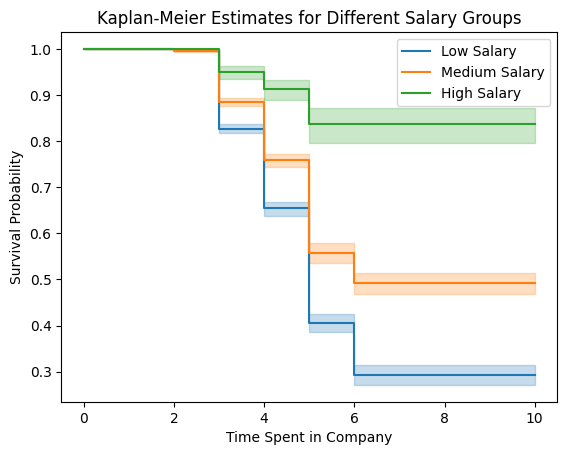

In [9]:
# Initialize the KaplanMeierFitter
kmf = KaplanMeierFitter()

# Define the salary categories
salary_categories = ['low', 'medium', 'high']

# Create a figure for plotting
plt.figure()

# Iterate through each salary category and fit the Kaplan-Meier curve
for salary in salary_categories:
    kmf.fit(data[data['salary'] == salary]['time_spend_company'], 
            event_observed=data[data['salary'] == salary]['left'], 
            label=f'{salary.capitalize()} Salary')
    kmf.plot()

# Add plot title and show the plot
plt.title('Kaplan-Meier Estimates for Different Salary Groups')
plt.xlabel('Time Spent in Company')
plt.ylabel('Survival Probability')
plt.show()



Kaplan Meier Survival Analysis Split by Job Groups

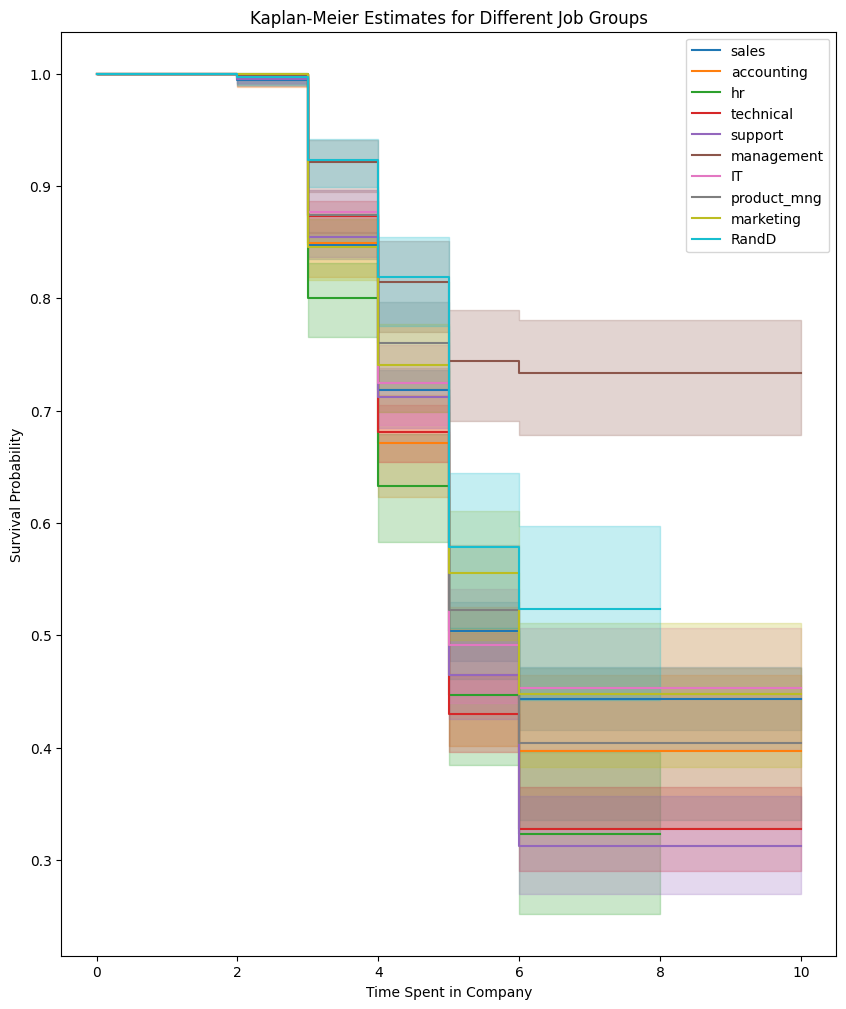

In [10]:
# Initialize the KaplanMeierFitter
kmf = KaplanMeierFitter()

# Define the job categories
job_categories = data['sales'].unique()

# Create a figure for plotting
plt.figure(figsize=(10,12))

# Iterate through each salary category and fit the Kaplan-Meier curve
for job in job_categories:
    kmf.fit(data[data['sales'] == job]['time_spend_company'], 
            event_observed=data[data['sales'] == job]['left'], 
            label=job)
    kmf.plot()

# Add plot title and show the plot
plt.title('Kaplan-Meier Estimates for Different Job Groups')
plt.xlabel('Time Spent in Company')
plt.ylabel('Survival Probability')
plt.show()

Cox Proportional Hazard Model Survival Analysis Split by Salary

In [11]:
cat_encoder = OneHotEncoder(sparse_output=False)
cat_onehot = cat_encoder.fit_transform(data[['sales', 'salary']])

encoded_df = pd.DataFrame(cat_onehot, columns=cat_encoder.get_feature_names_out(['sales', 'salary']))

data_encoded = pd.concat([data, encoded_df], axis=1)

data_encoded.drop(['sales', 'salary'], axis=1, inplace=True)

data_encoded.columns


Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'sales_IT', 'sales_RandD', 'sales_accounting',
       'sales_hr', 'sales_management', 'sales_marketing', 'sales_product_mng',
       'sales_sales', 'sales_support', 'sales_technical', 'salary_high',
       'salary_low', 'salary_medium'],
      dtype='object')

In [12]:
print(data[['sales', 'salary']].info())
print(data[['sales', 'salary']].nunique())
print(data[['sales', 'salary']].head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   sales   14999 non-null  object
 1   salary  14999 non-null  object
dtypes: object(2)
memory usage: 234.5+ KB
None
sales     10
salary     3
dtype: int64
   sales  salary
0  sales     low
1  sales  medium
2  sales  medium
3  sales     low
4  sales     low


In [13]:
cph = CoxPHFitter(penalizer=0.1)
cph.fit(data_encoded, duration_col='time_spend_company', event_col='left')

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 14999 total observations, 11428 right-censored observations>
             duration col = 'time_spend_company'
                event col = 'left'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 14999
number of events observed = 3571
   partial log-likelihood = -29851.58
         time fit was run = 2024-12-20 13:25:31 UTC

---
                        coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                                     
satisfaction_level     -1.68       0.19       0.05            -1.79            -1.57                 0.17                 0.21
last_evaluation        -0.37       0.69       0.09            -0.54            -0.20                 0.59                 0.82
number_project         -0.18       0.83       0.01            -0.21            -0.16                 0.81                 0.85
average_montly_hours    0.00       1.00       0.00            -0.00             0.00                 1.00                 1.00
Work_accident          -0.67       0.51       0.05            -0.76            -0.58                 0.47                 0.56
promotion_last_5years  -0.71       0.49       0.12            -0.94            -0.48                 0.39                 0.62
sales_IT               -0.07       0.93       0.06            -0.18             0.04                 0.84                 1.04
sales_RandD            -0.28       0.75       0.07            -0.42            -0.14                 0.66                 0.87
sales_accounting        0.03       1.03       0.07            -0.10             0.16                 0.91                 1.17
sales_hr                0.17       1.19       0.07             0.04             0.30                 1.05                 1.35
sales_management       -0.28       0.76       0.08            -0.43            -0.12                 0.65                 0.89
sales_marketing        -0.01       0.99       0.06            -0.14             0.11                 0.87                 1.12
sales_product_mng      -0.03       0.97       0.06            -0.15             0.10                 0.86                 1.10
sales_sales            -0.00       1.00       0.04            -0.08             0.07                 0.93                 1.07
sales_support           0.08       1.09       0.04            -0.00             0.17                 1.00                 1.19
sales_technical         0.09       1.09       0.04             0.01             0.17                 1.01                 1.18
salary_high            -0.62       0.54       0.07            -0.75            -0.49                 0.47                 0.61
salary_low              0.28       1.32       0.04             0.20             0.35                 1.22                 1.42
salary_medium          -0.09       0.91       0.04            -0.16            -0.01                 0.85                 0.99

                        cmp to      z      p   -log2(p)
covariate                                              
satisfaction_level        0.00 -30.85 <0.005     691.93
last_evaluation           0.00  -4.33 <0.005      16.06
number_project            0.00 -15.59 <0.005     179.57
average_montly_hours      0.00   1.47   0.14       2.82
Work_accident             0.00 -14.25 <0.005     150.70
promotion_last_5years     0.00  -5.98 <0.005      28.74
sales_IT                  0.00  -1.22   0.22       2.17
sales_RandD               0.00  -3.97 <0.005      13.79
sales_accounting          0.00   0.45   0.65       0.62
sales_hr                  0.00   2.65   0.01       6.95
sales_management          0.00  -3.41 <0.005      10.60
sales_marketing           0.00  -0.19   0.85       0.24
sales_product_mng         0.00  -0.46   0.64       0.63
sales_sales               0.00  -0.09   0.93     

<Axes: xlabel='log(HR) (95% CI)'>

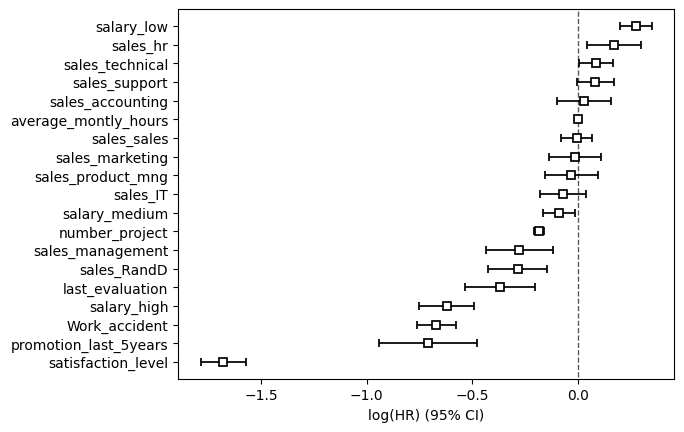

In [14]:
cph.plot()

<Axes: xlabel='HR (95% CI)'>

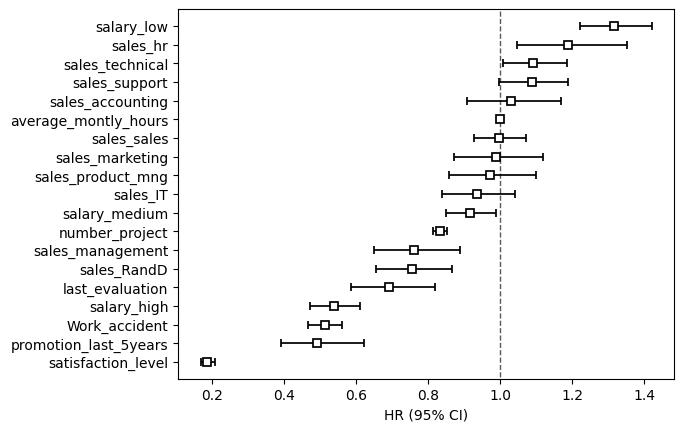

In [15]:
cph.plot(hazard_ratios=True)

<Axes: >

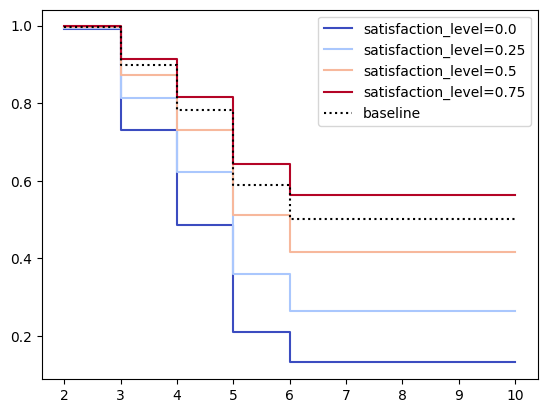

In [16]:
cph.plot_partial_effects_on_outcome(
    covariates = 'satisfaction_level',
    values= np.arange(0,1,0.25),
    cmap = 'coolwarm'
)

In [17]:
from lifelines import WeibullFitter, ExponentialFitter, LogNormalFitter, LogLogisticFitter

In [18]:
wb = WeibullFitter()
ex = ExponentialFitter()
log = LogNormalFitter()
loglogis = LogLogisticFitter()

for model in [wb,ex, log, loglogis]:
    model.fit(data_encoded['time_spend_company'],
                data_encoded['left'])
    print("The Akaike information criterion (AIC) for ", model.__class__.__name__, "is ", model.AIC_)

The Akaike information criterion (AIC) for  WeibullFitter is  21062.028142649287
The Akaike information criterion (AIC) for  ExponentialFitter is  26337.381582694656
The Akaike information criterion (AIC) for  LogNormalFitter is  19323.17661159538
The Akaike information criterion (AIC) for  LogLogisticFitter is  19697.41871960109


In [19]:
employee_sample = data_encoded.iloc[5:10]

In [20]:
employee_sample

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales_IT,sales_RandD,...,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_high,salary_low,salary_medium
5,0.41,0.50,2,153,3,0,1,0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
6,0.10,0.77,6,247,4,0,1,0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
7,0.92,0.85,5,259,5,0,1,0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
8,0.89,1.00,5,224,5,0,1,0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
9,0.42,0.53,2,142,3,0,1,0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


<Axes: >

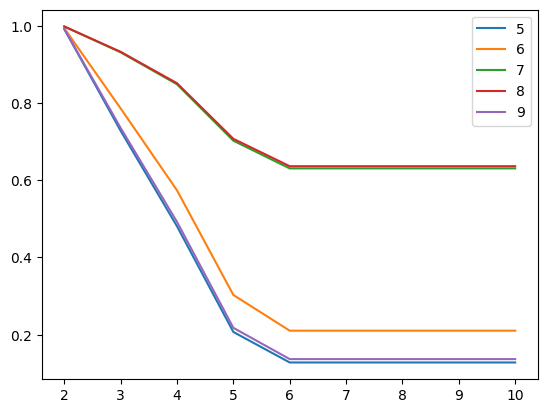

In [21]:
cph.predict_survival_function(employee_sample).plot()